# Probing SSL Embeddings (Pre-trained)

This notebook probes DreaMS **SSL embeddings** (pre-trained, non-fine-tuned) to understand what molecular properties they encode.

## Research Questions
- What molecular descriptors can be predicted from SSL embeddings?
- Are SSL embeddings encoding compositional/structural features?
- Does multi-task learning improve probing performance?

## Descriptors to Probe (10 RDKit properties)
1. **AlogP** - Lipophilicity (log partition coefficient)
2. **HBA** - Hydrogen Bond Acceptors
3. **HBD** - Hydrogen Bond Donors  
4. **TPSA** - Topological Polar Surface Area
5. **#RotBonds** - Number of Rotatable Bonds (flexibility)
6. **#AromRings** - Number of Aromatic Rings
7. **#AliphRings** - Number of Aliphatic Rings
8. **Fsp3** - Fraction of sp3 carbons (saturation)
9. **QED** - Quantitative Estimate of Drug-likeness
10. **SA Score** - Synthetic Accessibility Score

## Approach
- **Embeddings**: SSL only (from `ssl_model.ckpt`)
- **Data splits**: Murcko histogram-based (prevents similar scaffold leakage)
- **Probes**: Linear and MLP (single-task) + Multi-task with shared trunk
- **Total models**: 20 single-task + 1 multi-task = 21 models
- **Runtime**: ~15 minutes on Apple MPS GPU

## 1. Import Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from tqdm import tqdm

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

## 2. Load Data with Embeddings and Descriptors

In [47]:
# Load parquet file with both embeddings and descriptors
# Using Murcko histogram-based splits (more rigorous than scaffold splits)
data_path = Path('../data/processed/massspecgym_complete/ssl_embs/MassSpecGym_with_SSL_embeddings_murcko_hist_splits.parquet')
df = pd.read_parquet(data_path)

print(f"Total samples: {len(df):,}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData splits:")
print(df['fold'].value_counts())

Total samples: 231,104

Columns: ['identifier', 'mzs', 'intensities', 'smiles', 'inchikey', 'formula', 'precursor_formula', 'parent_mass', 'precursor_mz', 'adduct', 'instrument_type', 'collision_energy', 'simulation_challenge', 'scaffold_id', 'murcko_scaffold', 'ecfp4', 'map4', 'embedding', 'ssl_embedding', 'alogp', 'hba', 'hbd', 'tpsa', 'n_rotatable_bonds', 'n_aromatic_rings', 'n_aliphatic_rings', 'fsp3', 'qed', 'sa_score', 'fold']

Data splits:
fold
train    159271
test      45185
val       26648
Name: count, dtype: int64


## 3. Prepare Train/Val/Test Splits

In [48]:
# Split by existing fold column
df_train = df[df['fold'] == 'train'].copy()
df_val = df[df['fold'] == 'val'].copy()
df_test = df[df['fold'] == 'test'].copy()

print(f"Train: {len(df_train):,} samples")
print(f"Val:   {len(df_val):,} samples")
print(f"Test:  {len(df_test):,} samples")

# Define target descriptors (10 RDKit properties)
target_descriptors = [
    'alogp', 'hba', 'hbd', 'tpsa', 
    'n_rotatable_bonds', 'n_aromatic_rings', 'n_aliphatic_rings',
    'fsp3', 'qed', 'sa_score'
]

print(f"\nTarget descriptors: {target_descriptors}")

Train: 159,271 samples
Val:   26,648 samples
Test:  45,185 samples

Target descriptors: ['alogp', 'hba', 'hbd', 'tpsa', 'n_rotatable_bonds', 'n_aromatic_rings', 'n_aliphatic_rings', 'fsp3', 'qed', 'sa_score']


## 4. Define Probe Models

In [49]:
class LinearProbe(nn.Module):
    """Simple linear regression probe"""
    def __init__(self, input_dim, output_dim=1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    
    def forward(self, x):
        return self.linear(x)


class MLPProbe(nn.Module):
    """Multi-layer perceptron probe"""
    def __init__(self, input_dim, hidden_dim=256, output_dim=1, dropout=0.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )
    
    def forward(self, x):
        return self.network(x)


# PyTorch Dataset
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, targets):
        self.embeddings = torch.FloatTensor(embeddings)
        self.targets = torch.FloatTensor(targets).unsqueeze(1)  # (N, 1)
    
    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.targets[idx]


print("✓ Probe models defined")

✓ Probe models defined


In [50]:
class MultiTaskProbe(nn.Module):
    """
    Multi-task probe with shared trunk and task-specific heads.
    
    Architecture:
    - Shared trunk: processes frozen embedding into shared representation
    - Regression head: predicts continuous descriptors (10 outputs)
    - Can be extended with binary classification head for substructures
    """
    def __init__(self, input_dim, trunk_dim=128, n_regression_tasks=10, dropout=0.2):
        super().__init__()
        
        # Shared trunk (small MLP on frozen embedding)
        self.trunk = nn.Sequential(
            nn.Linear(input_dim, trunk_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Task-specific heads
        self.regression_head = nn.Linear(trunk_dim, n_regression_tasks)
        
        self.n_regression_tasks = n_regression_tasks
    
    def forward(self, x):
        # Shared representation
        h = self.trunk(x)  # (batch, trunk_dim)
        
        # Regression predictions (all 10 descriptors)
        y_reg = self.regression_head(h)  # (batch, 10)
        
        return y_reg


print("✓ Multi-task probe model defined")

✓ Multi-task probe model defined


In [51]:
# Multi-task Dataset (returns all 10 targets at once)
class MultiTaskDataset(Dataset):
    def __init__(self, embeddings, targets):
        """
        Args:
            embeddings: (N, embedding_dim) array
            targets: (N, n_tasks) array - all normalized targets
        """
        self.embeddings = torch.FloatTensor(embeddings)
        self.targets = torch.FloatTensor(targets)  # (N, 10)
    
    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.targets[idx]


print("✓ Multi-task dataset defined")

✓ Multi-task dataset defined


## 5. Training & Evaluation Functions

In [52]:
def train_probe(model, train_loader, val_loader, epochs=50, lr=0.001, device='cpu'):
    """Train a probe model"""
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for embeddings, targets in train_loader:
            embeddings, targets = embeddings.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(embeddings)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for embeddings, targets in val_loader:
                embeddings, targets = embeddings.to(device), targets.to(device)
                outputs = model(embeddings)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    return model, train_losses, val_losses


def evaluate_probe(model, test_loader, device='cpu'):
    """Evaluate probe model"""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for embeddings, targets in test_loader:
            embeddings = embeddings.to(device)
            outputs = model(embeddings)
            # Collect predictions and targets (use .tolist() to avoid numpy conversion issues)
            all_preds.extend(outputs.cpu().tolist())
            all_targets.extend(targets.cpu().tolist())
    
    # Convert lists to numpy arrays
    all_preds = np.array(all_preds).flatten()
    all_targets = np.array(all_targets).flatten()
    
    r2 = r2_score(all_targets, all_preds)
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    
    return {
        'r2': r2,
        'mae': mae,
        'rmse': rmse,
        'predictions': all_preds,
        'targets': all_targets
    }


print("✓ Training functions defined")

✓ Training functions defined


In [53]:
def train_multitask_probe(model, train_loader, val_loader, epochs=50, lr=0.001, device='cpu'):
    """Train multi-task probe model"""
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for embeddings, targets in train_loader:
            embeddings, targets = embeddings.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(embeddings)  # (batch, 10)
            loss = criterion(outputs, targets)  # MSE across all tasks
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for embeddings, targets in val_loader:
                embeddings, targets = embeddings.to(device), targets.to(device)
                outputs = model(embeddings)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    return model, train_losses, val_losses


def evaluate_multitask_probe(model, test_loader, scalers, descriptor_names, device='cpu'):
    """
    Evaluate multi-task probe model.
    
    Args:
        model: trained multi-task model
        test_loader: test data loader
        scalers: list of StandardScaler objects (one per descriptor)
        descriptor_names: list of descriptor names
        device: computation device
    
    Returns:
        dict: results per descriptor {descriptor_name: {r2, mae, rmse}}
    """
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for embeddings, targets in test_loader:
            embeddings = embeddings.to(device)
            outputs = model(embeddings)  # (batch, 10)
            # Collect predictions and targets (use .tolist() to avoid numpy conversion issues)
            all_preds.extend(outputs.cpu().tolist())
            all_targets.extend(targets.cpu().tolist())
    
    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)  # (n_samples, 10)
    all_targets = np.array(all_targets)  # (n_samples, 10)
    
    # Evaluate each descriptor separately
    results = {}
    for i, desc_name in enumerate(descriptor_names):
        # Inverse transform predictions and targets for this descriptor
        preds_original = scalers[i].inverse_transform(all_preds[:, i].reshape(-1, 1)).flatten()
        targets_original = scalers[i].inverse_transform(all_targets[:, i].reshape(-1, 1)).flatten()
        
        r2 = r2_score(targets_original, preds_original)
        mae = mean_absolute_error(targets_original, preds_original)
        rmse = np.sqrt(mean_squared_error(targets_original, preds_original))
        
        results[desc_name] = {
            'r2': r2,
            'mae': mae,
            'rmse': rmse
        }
    
    return results


print("✓ Multi-task training functions defined")

✓ Multi-task training functions defined


## 6. Run Probing Experiments

We'll probe SSL embeddings on all 10 descriptors using Linear and MLP probes.

In [54]:
# Device setup - using CPU to avoid MPS/NumPy compatibility issues
device = 'cpu'  # Force CPU for now (MPS has numpy conversion issues)
print(f"Using device: {device}")
print("(Note: Using CPU due to MPS/NumPy compatibility. Will be slower but more stable.)")

# Extract embeddings
ssl_embeddings_train = np.vstack(df_train['ssl_embedding'].values)
ssl_embeddings_val = np.vstack(df_val['ssl_embedding'].values)
ssl_embeddings_test = np.vstack(df_test['ssl_embedding'].values)

print(f"\nSSL embeddings shape: {ssl_embeddings_train.shape}")

# Hyperparameters
BATCH_SIZE = 256
EPOCHS = 30
LEARNING_RATE = 0.001
EMBEDDING_DIM = ssl_embeddings_train.shape[1]

print(f"\nHyperparameters:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Embedding dim: {EMBEDDING_DIM}")

Using device: cpu
(Note: Using CPU due to MPS/NumPy compatibility. Will be slower but more stable.)

SSL embeddings shape: (159271, 1024)

Hyperparameters:
  Batch size: 256
  Epochs: 30
  Learning rate: 0.001
  Embedding dim: 1024


## 6a. Option: Load Previously Saved Results

If you've already run the experiments and saved results, you can load them here to skip re-training.

In [27]:
import pickle
from pathlib import Path

results_path = Path('../results/ssl_probing_results.pkl')

if results_path.exists():
    print(f"📂 Loading saved results from: {results_path}")
    with open(results_path, 'rb') as f:
        results = pickle.load(f)
    
    results_df = pd.DataFrame(results)
    print(f"✅ Loaded {len(results_df)} experiment results")
    print("\nFirst few results:")
    print(results_df.head())
    
    # Skip to Section 7 for visualizations
    print("\n💡 You can now skip to Section 7 to visualize these results")
else:
    print(f"❌ No saved results found at: {results_path}")
    print("   You'll need to run Sections 6-6c to generate results (takes ~25 minutes)")
    results = None

❌ No saved results found at: ../results/ssl_probing_results.pkl
   You'll need to run Sections 6-6c to generate results (takes ~25 minutes)


## 6b. Diagnose Data Issues

Let's check the descriptor distributions to understand if there are any problems.

In [16]:
# Check descriptor statistics to identify potential issues
print("="*80)
print("DESCRIPTOR STATISTICS - CHECKING FOR ISSUES")
print("="*80)

for desc in target_descriptors:
    print(f"\n{desc}:")
    print(f"  Train - Mean: {df_train[desc].mean():.4f}, Std: {df_train[desc].std():.4f}, Min: {df_train[desc].min():.4f}, Max: {df_train[desc].max():.4f}")
    print(f"  Val   - Mean: {df_val[desc].mean():.4f}, Std: {df_val[desc].std():.4f}")
    print(f"  Test  - Mean: {df_test[desc].mean():.4f}, Std: {df_test[desc].std():.4f}")
    
    # Check for constant or near-constant values
    if df_train[desc].std() < 0.01:
        print(f"  ⚠️  WARNING: Very low variance! Descriptor is nearly constant.")
    
    # Check value counts for low-cardinality descriptors
    n_unique = df_train[desc].nunique()
    print(f"  Unique values: {n_unique}")
    
    if n_unique < 20:
        print(f"  Value distribution:")
        print(df_train[desc].value_counts().head(10))

print("\n" + "="*80)

DESCRIPTOR STATISTICS - CHECKING FOR ISSUES

alogp:
  Train - Mean: 2.8715, Std: 3.0081, Min: -13.0548, Max: 17.5988
  Val   - Mean: 2.2618, Std: 2.5705
  Test  - Mean: 2.4694, Std: 2.1202
  Unique values: 20993

hba:
  Train - Mean: 5.7732, Std: 3.7120, Min: 0.0000, Max: 30.0000
  Val   - Mean: 6.9899, Std: 4.5270
  Test  - Mean: 6.3853, Std: 4.0647
  Unique values: 29

hbd:
  Train - Mean: 2.3064, Std: 2.3773, Min: 0.0000, Max: 18.0000
  Val   - Mean: 3.0452, Std: 3.1084
  Test  - Mean: 2.4083, Std: 2.6518
  Unique values: 19
  Value distribution:
hbd
1    45786
2    40330
0    36758
3    23400
4    11799
5     6192
6     5262
7     3756
8     2934
9     2388
Name: count, dtype: int64

tpsa:
  Train - Mean: 95.3229, Std: 60.0524, Min: 0.0000, Max: 476.4600
  Val   - Mean: 114.1665, Std: 76.1195
  Test  - Mean: 99.5548, Std: 67.6328
  Unique values: 7223

n_rotatable_bonds:
  Train - Mean: 7.0752, Std: 8.7320, Min: 0.0000, Max: 50.0000
  Val   - Mean: 5.3036, Std: 4.9040
  Test  - Mea

In [55]:
# Store results
results = {
    'descriptor': [],
    'embedding_type': [],
    'probe_type': [],
    'r2': [],
    'mae': [],
    'rmse': []
}

# Probe each descriptor
for descriptor in target_descriptors:
    print(f"\n{'='*60}")
    print(f"Probing: {descriptor}")
    print(f"{'='*60}")
    
    # Get targets
    y_train = df_train[descriptor].values
    y_val = df_val[descriptor].values
    y_test = df_test[descriptor].values
    
    # Standardize targets (z-score normalization for single-task)
    scaler = StandardScaler()
    y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = scaler.transform(y_val.reshape(-1, 1)).flatten()
    y_test_scaled = scaler.transform(y_test.reshape(-1, 1)).flatten()
    
    # Test SSL embeddings only with both probe types
    emb_type = 'SSL'
    X_train, X_val, X_test = ssl_embeddings_train, ssl_embeddings_val, ssl_embeddings_test
    
    for probe_name, ProbeClass in [('Linear', LinearProbe), ('MLP', MLPProbe)]:
            print(f"\n{emb_type} + {probe_name} Probe:")
            
            # Create datasets
            train_dataset = EmbeddingDataset(X_train, y_train_scaled)
            val_dataset = EmbeddingDataset(X_val, y_val_scaled)
            test_dataset = EmbeddingDataset(X_test, y_test_scaled)
            
            train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
            test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
            
            # Train probe
            model = ProbeClass(input_dim=EMBEDDING_DIM)
            model, train_losses, val_losses = train_probe(
                model, train_loader, val_loader, 
                epochs=EPOCHS, lr=LEARNING_RATE, device=device
            )
            
            # Evaluate
            eval_results = evaluate_probe(model, test_loader, device=device)
            
            # Inverse transform predictions for proper metrics
            preds_original = scaler.inverse_transform(eval_results['predictions'].reshape(-1, 1)).flatten()
            
            # Recalculate metrics on original scale
            r2 = r2_score(y_test, preds_original)
            mae = mean_absolute_error(y_test, preds_original)
            rmse = np.sqrt(mean_squared_error(y_test, preds_original))
            
            print(f"  R²: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")
            
            # Store results
            results['descriptor'].append(descriptor)
            results['embedding_type'].append(emb_type)
            results['probe_type'].append(probe_name)
            results['r2'].append(r2)
            results['mae'].append(mae)
            results['rmse'].append(rmse)

print("\n✓ All probing experiments complete!")


Probing: alogp

SSL + Linear Probe:
Epoch 10/30 - Train Loss: 0.4499, Val Loss: 0.3716
Epoch 10/30 - Train Loss: 0.4499, Val Loss: 0.3716
Epoch 20/30 - Train Loss: 0.4496, Val Loss: 0.3668
Epoch 20/30 - Train Loss: 0.4496, Val Loss: 0.3668
Epoch 30/30 - Train Loss: 0.4484, Val Loss: 0.3624
Epoch 30/30 - Train Loss: 0.4484, Val Loss: 0.3624
  R²: -0.0315, MAE: 1.5110, RMSE: 1.9933

SSL + MLP Probe:
  R²: -0.0315, MAE: 1.5110, RMSE: 1.9933

SSL + MLP Probe:
Epoch 10/30 - Train Loss: 0.1429, Val Loss: 0.2849
Epoch 10/30 - Train Loss: 0.1429, Val Loss: 0.2849
Epoch 20/30 - Train Loss: 0.1072, Val Loss: 0.2866
Epoch 20/30 - Train Loss: 0.1072, Val Loss: 0.2866
Epoch 30/30 - Train Loss: 0.0911, Val Loss: 0.2923
Epoch 30/30 - Train Loss: 0.0911, Val Loss: 0.2923
  R²: 0.1516, MAE: 1.3456, RMSE: 1.8078

Probing: hba

SSL + Linear Probe:
  R²: 0.1516, MAE: 1.3456, RMSE: 1.8078

Probing: hba

SSL + Linear Probe:
Epoch 10/30 - Train Loss: 0.4457, Val Loss: 0.3972
Epoch 10/30 - Train Loss: 0.4457

In [57]:
# Save results to disk for later use
import pickle
results_save_path = Path('../results/probing_results_ssl.pkl')
results_save_path.parent.mkdir(parents=True, exist_ok=True)

with open(results_save_path, 'wb') as f:
    pickle.dump(results, f)

print(f"✓ Results saved to {results_save_path}")

✓ Results saved to ../results/probing_results_ssl.pkl


## 7. Results Summary

In [58]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display full results
print("="*80)
print("PROBING RESULTS - ALL EXPERIMENTS")
print("="*80)
print(results_df.to_string(index=False))

# Summary by descriptor (best R² for each)
print("\n" + "="*80)
print("BEST R² BY DESCRIPTOR")
print("="*80)
best_by_descriptor = results_df.loc[results_df.groupby('descriptor')['r2'].idxmax()]
print(best_by_descriptor[['descriptor', 'embedding_type', 'probe_type', 'r2']].to_string(index=False))

PROBING RESULTS - ALL EXPERIMENTS
       descriptor embedding_type probe_type        r2       mae      rmse
            alogp            SSL     Linear -0.031507  1.511008  1.993334
            alogp            SSL        MLP  0.151560  1.345622  1.807817
              hba            SSL     Linear  0.366694  1.936992  2.700887
              hba            SSL        MLP  0.416674  1.892868  2.592120
              hbd            SSL     Linear -0.136520  1.425223  1.845708
              hbd            SSL        MLP  0.038531  1.254193  1.697626
             tpsa            SSL     Linear  0.290235 33.448021 44.035463
             tpsa            SSL        MLP  0.369818 30.695761 41.493354
n_rotatable_bonds            SSL     Linear -0.760190  3.595031  4.521952
n_rotatable_bonds            SSL        MLP -0.000800  2.715342  3.409728
 n_aromatic_rings            SSL     Linear  0.081705  0.760267  0.942767
 n_aromatic_rings            SSL        MLP -0.016051  0.787313  0.991679
n_al

## 8. Visualize Results

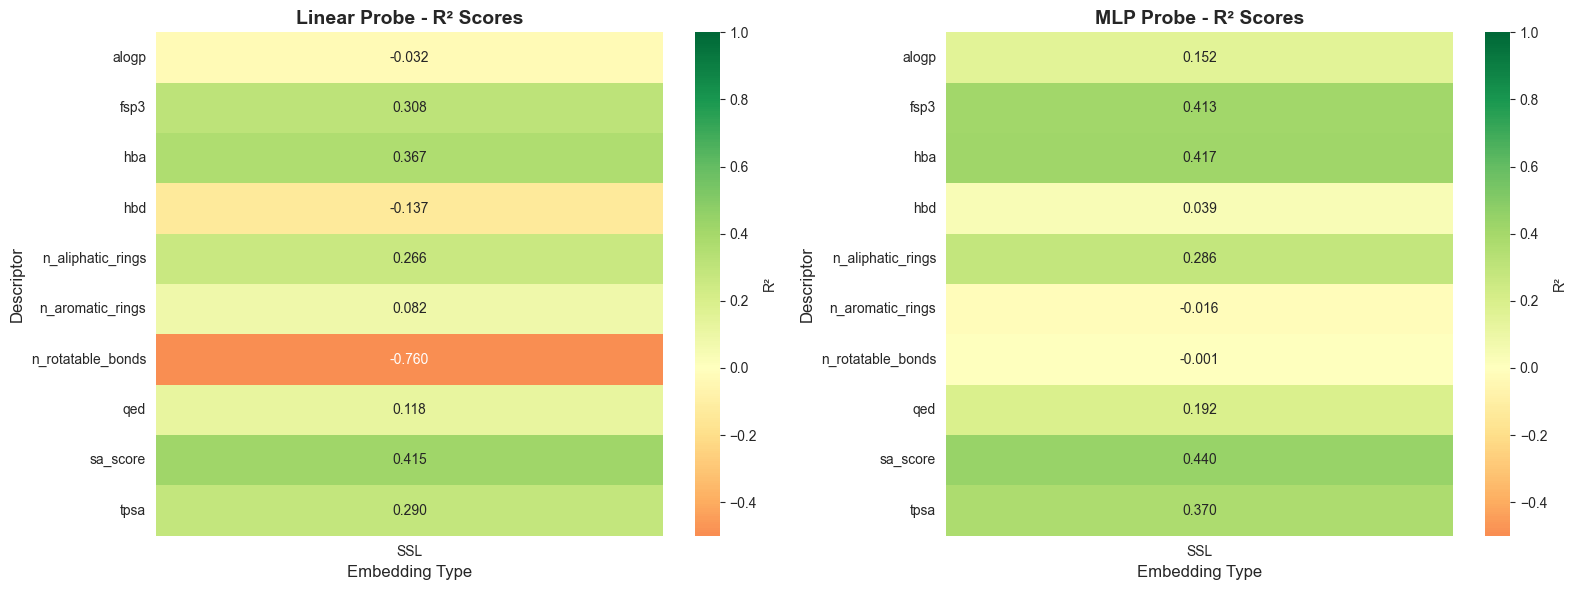

In [59]:
# 1. Heatmap: R² scores for all combinations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, probe_type in enumerate(['Linear', 'MLP']):
    df_subset = results_df[results_df['probe_type'] == probe_type]
    pivot = df_subset.pivot(index='descriptor', columns='embedding_type', values='r2')
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0, 
                vmin=-0.5, vmax=1.0, ax=axes[idx], cbar_kws={'label': 'R²'})
    axes[idx].set_title(f'{probe_type} Probe - R² Scores', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Embedding Type', fontsize=12)
    axes[idx].set_ylabel('Descriptor', fontsize=12)

plt.tight_layout()
plt.show()

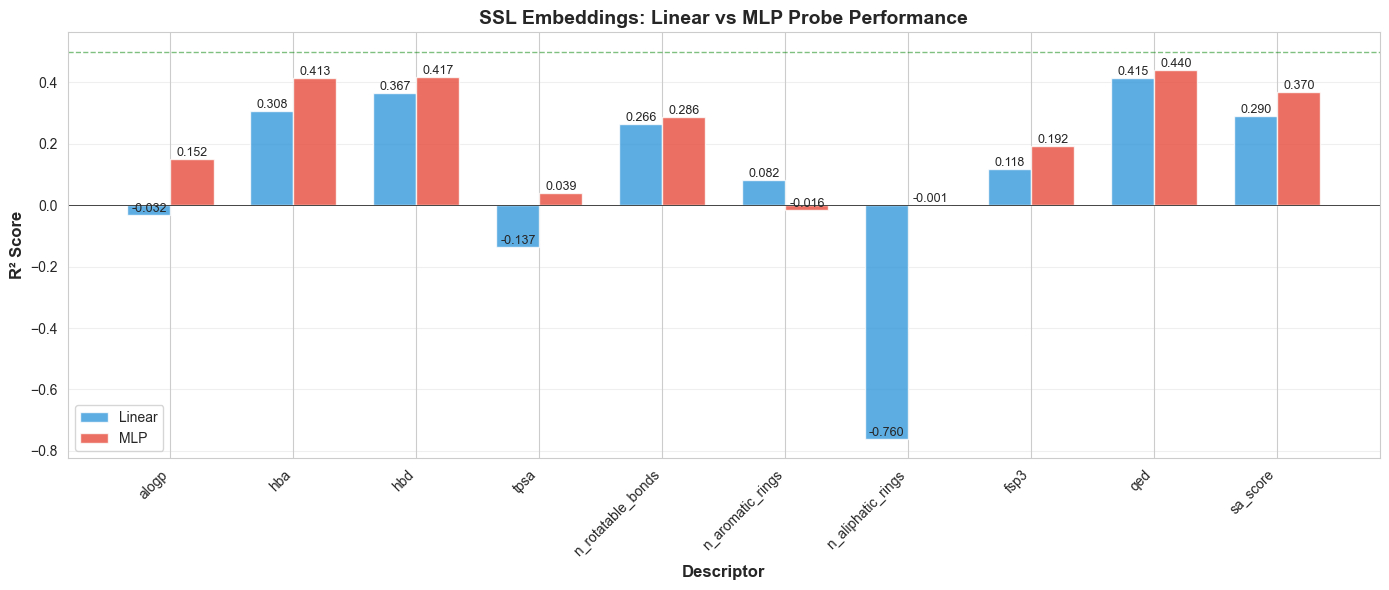

In [60]:
# Bar plot: Linear vs MLP comparison for SSL embeddings
fig, ax = plt.subplots(figsize=(14, 6))

# Get results for Linear and MLP
linear_results = results_df[results_df['probe_type'] == 'Linear'].sort_values('descriptor')
mlp_results = results_df[results_df['probe_type'] == 'MLP'].sort_values('descriptor')

x = np.arange(len(target_descriptors))
width = 0.35

bars1 = ax.bar(x - width/2, linear_results['r2'].values, width, label='Linear', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, mlp_results['r2'].values, width, label='MLP', color='#e74c3c', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Descriptor', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('SSL Embeddings: Linear vs MLP Probe Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(target_descriptors, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axhline(y=0.5, color='green', linestyle='--', linewidth=1, alpha=0.5, label='R²=0.5 (decent encoding)')

plt.tight_layout()
plt.show()

In [36]:
# 3. Summary statistics
print("\n" + "="*80)
print("SUMMARY: SSL vs CONTRASTIVE")
print("="*80)

for emb_type in ['SSL', 'Contrastive']:
    subset = results_df[results_df['embedding_type'] == emb_type]
    mean_r2 = subset['r2'].mean()
    max_r2 = subset['r2'].max()
    min_r2 = subset['r2'].min()
    
    print(f"\n{emb_type} Embeddings:")
    print(f"  Mean R²: {mean_r2:.4f}")
    print(f"  Max R²:  {max_r2:.4f}")
    print(f"  Min R²:  {min_r2:.4f}")
    print(f"  Descriptors with R² > 0.5: {(subset['r2'] > 0.5).sum()}")

print("\n" + "="*80)


SUMMARY: SSL vs CONTRASTIVE

SSL Embeddings:
  Mean R²: 0.3598
  Max R²:  0.5788
  Min R²:  -0.5116
  Descriptors with R² > 0.5: 4

Contrastive Embeddings:
  Mean R²: nan
  Max R²:  nan
  Min R²:  nan
  Descriptors with R² > 0.5: 0



## 9. Multi-Task Learning Experiments

Now let's compare single-task vs multi-task learning with a shared trunk.

In [61]:
# Prepare multi-task targets (all 10 descriptors normalized together)
print("Preparing multi-task data...")

# Collect all targets
y_train_all = df_train[target_descriptors].values  # (N_train, 10)
y_val_all = df_val[target_descriptors].values      # (N_val, 10)
y_test_all = df_test[target_descriptors].values    # (N_test, 10)

# Normalize each descriptor to [0, 1] separately (store scalers for inverse transform)
scalers = []
y_train_normalized = np.zeros_like(y_train_all, dtype=np.float32)
y_val_normalized = np.zeros_like(y_val_all, dtype=np.float32)
y_test_normalized = np.zeros_like(y_test_all, dtype=np.float32)

for i, desc in enumerate(target_descriptors):
    scaler = MinMaxScaler()
    y_train_normalized[:, i] = scaler.fit_transform(y_train_all[:, i].reshape(-1, 1)).flatten()
    y_val_normalized[:, i] = scaler.transform(y_val_all[:, i].reshape(-1, 1)).flatten()
    y_test_normalized[:, i] = scaler.transform(y_test_all[:, i].reshape(-1, 1)).flatten()
    scalers.append(scaler)

print(f"✓ Normalized targets shape: {y_train_normalized.shape}")
print(f"✓ Created {len(scalers)} MinMaxScalers (one per descriptor)")
print(f"✓ All targets normalized to [0, 1] range")

Preparing multi-task data...
✓ Normalized targets shape: (159271, 10)
✓ Created 10 MinMaxScalers (one per descriptor)
✓ All targets normalized to [0, 1] range


In [62]:
# Train multi-task model for SSL embeddings only
multitask_results = {}

emb_type = 'SSL'
X_train, X_val, X_test = ssl_embeddings_train, ssl_embeddings_val, ssl_embeddings_test

print(f"\n{'='*60}")
print(f"Multi-Task Learning: {emb_type} Embeddings")
print(f"{'='*60}")

# Create multi-task datasets
train_dataset = MultiTaskDataset(X_train, y_train_normalized)
val_dataset = MultiTaskDataset(X_val, y_val_normalized)
test_dataset = MultiTaskDataset(X_test, y_test_normalized)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Train multi-task model
trunk_dim = min(128, EMBEDDING_DIM // 4)  # Small trunk for probing
model = MultiTaskProbe(
    input_dim=EMBEDDING_DIM, 
    trunk_dim=trunk_dim,
    n_regression_tasks=len(target_descriptors)
)

print(f"Trunk dimension: {trunk_dim}")
print(f"Training...")

model, train_losses, val_losses = train_multitask_probe(
    model, train_loader, val_loader, 
    epochs=EPOCHS, lr=LEARNING_RATE, device=device
)

# Evaluate
print("\nEvaluating...")
results = evaluate_multitask_probe(
    model, test_loader, scalers, target_descriptors, device=device
)

multitask_results[emb_type] = results

# Print results
print(f"\n{emb_type} Multi-Task Results:")
print("-" * 50)
for desc, metrics in results.items():
    print(f"{desc:20s}: R²={metrics['r2']:7.4f}, MAE={metrics['mae']:7.4f}, RMSE={metrics['rmse']:7.4f}")

print("\n✓ Multi-task experiments complete!")


Multi-Task Learning: SSL Embeddings
Trunk dimension: 128
Training...
Epoch 10/30 - Train Loss: 0.0106, Val Loss: 0.0150
Epoch 10/30 - Train Loss: 0.0106, Val Loss: 0.0150
Epoch 20/30 - Train Loss: 0.0096, Val Loss: 0.0150
Epoch 20/30 - Train Loss: 0.0096, Val Loss: 0.0150
Epoch 30/30 - Train Loss: 0.0092, Val Loss: 0.0148

Evaluating...
Epoch 30/30 - Train Loss: 0.0092, Val Loss: 0.0148

Evaluating...

SSL Multi-Task Results:
--------------------------------------------------
alogp               : R²= 0.1058, MAE= 1.3771, RMSE= 1.8559
hba                 : R²= 0.4181, MAE= 1.9467, RMSE= 2.5891
hbd                 : R²= 0.0672, MAE= 1.2714, RMSE= 1.6721
tpsa                : R²= 0.3624, MAE=31.9619, RMSE=41.7364
n_rotatable_bonds   : R²=-0.0530, MAE= 2.8019, RMSE= 3.4975
n_aromatic_rings    : R²= 0.0941, MAE= 0.7414, RMSE= 0.9364
n_aliphatic_rings   : R²= 0.3135, MAE= 1.0019, RMSE= 1.3783
fsp3                : R²= 0.4109, MAE= 0.1564, RMSE= 0.1963
qed                 : R²= 0.2025, MAE=

## 10. Compare Single-Task vs Multi-Task

In [67]:
# Create comparison dataframe for SSL only
comparison_data = []

emb_type = 'SSL'

# Add single-task best results
for desc in target_descriptors:
    # Get best single-task result for this descriptor (SSL only)
    subset = results_df[results_df['descriptor'] == desc]
    best_single = subset.loc[subset['r2'].idxmax()]
    
    comparison_data.append({
        'descriptor': desc,
        'approach': 'Single-Task (Best)',
        'probe_type': best_single['probe_type'],
        'r2': best_single['r2'],
        'mae': best_single['mae'],
        'rmse': best_single['rmse']
    })

# Add multi-task results
for desc in target_descriptors:
    mt_metrics = multitask_results[emb_type][desc]
    
    comparison_data.append({
        'descriptor': desc,
        'approach': 'Multi-Task',
        'probe_type': 'Shared Trunk',
        'r2': mt_metrics['r2'],
        'mae': mt_metrics['mae'],
        'rmse': mt_metrics['rmse']
    })

comparison_df = pd.DataFrame(comparison_data)

print("="*80)
print("SINGLE-TASK vs MULTI-TASK COMPARISON (SSL Embeddings)")
print("="*80)
print(comparison_df.to_string(index=False))

SINGLE-TASK vs MULTI-TASK COMPARISON (SSL Embeddings)
       descriptor           approach   probe_type        r2       mae      rmse
            alogp Single-Task (Best)          MLP  0.151560  1.345622  1.807817
              hba Single-Task (Best)          MLP  0.416674  1.892868  2.592120
              hbd Single-Task (Best)          MLP  0.038531  1.254193  1.697626
             tpsa Single-Task (Best)          MLP  0.369818 30.695761 41.493354
n_rotatable_bonds Single-Task (Best)          MLP -0.000800  2.715342  3.409728
 n_aromatic_rings Single-Task (Best)       Linear  0.081705  0.760267  0.942767
n_aliphatic_rings Single-Task (Best)          MLP  0.286136  0.993655  1.405504
             fsp3 Single-Task (Best)          MLP  0.412938  0.153471  0.195922
              qed Single-Task (Best)          MLP  0.191917  0.145898  0.184717
         sa_score Single-Task (Best)          MLP  0.439846  0.812834  1.114833
            alogp         Multi-Task Shared Trunk  0.105848  1.377

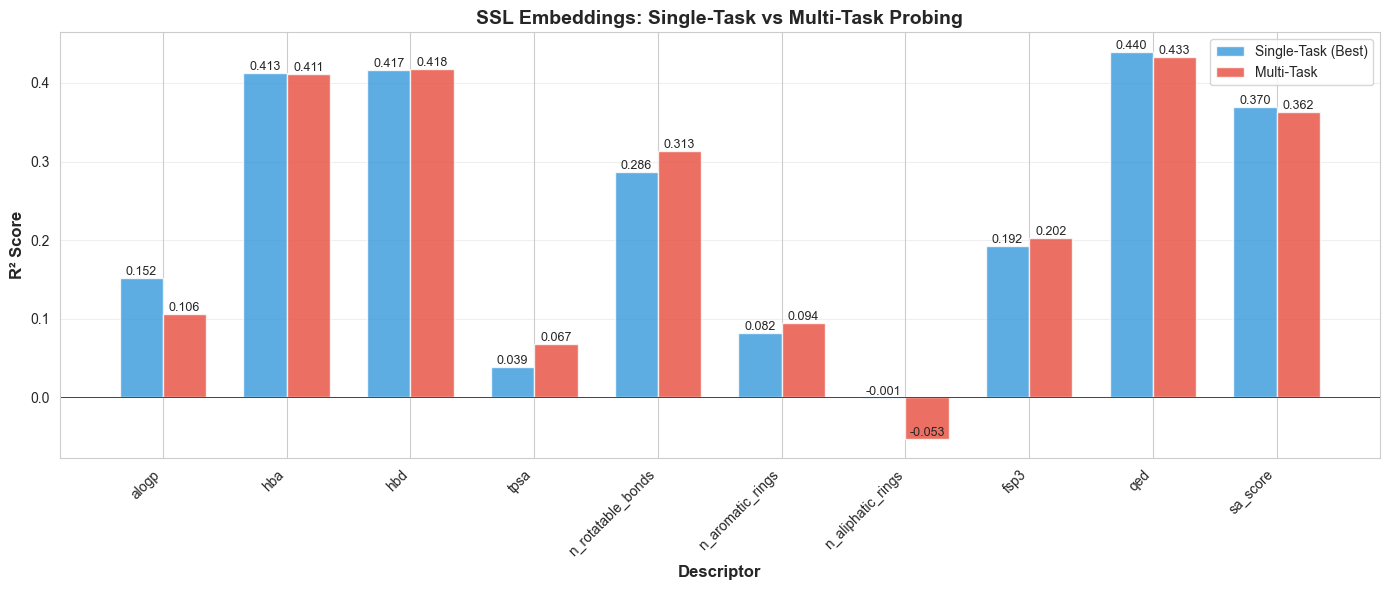

In [68]:
# Visualize comparison: Single-Task vs Multi-Task for SSL
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Pivot for plotting
pivot = comparison_df.pivot(index='descriptor', columns='approach', values='r2')

x = np.arange(len(target_descriptors))
width = 0.35

single_task = pivot['Single-Task (Best)'].values
multi_task = pivot['Multi-Task'].values

bars1 = ax.bar(x - width/2, single_task, width, 
                      label='Single-Task (Best)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, multi_task, width, 
                      label='Multi-Task', color='#e74c3c', alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Descriptor', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('SSL Embeddings: Single-Task vs Multi-Task Probing', 
                   fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(target_descriptors, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

In [69]:
# Summary: Which approach wins for SSL?
print("\n" + "="*80)
print("SUMMARY: SINGLE-TASK vs MULTI-TASK (SSL Embeddings)")
print("="*80)

single_task_r2 = comparison_df[comparison_df['approach'] == 'Single-Task (Best)']['r2'].values
multi_task_r2 = comparison_df[comparison_df['approach'] == 'Multi-Task']['r2'].values

improvements = multi_task_r2 - single_task_r2

print(f"\nSSL Embeddings:")
print(f"  Multi-task wins: {(improvements > 0).sum()}/{len(improvements)} descriptors")
print(f"  Mean R² improvement: {improvements.mean():+.4f}")
print(f"  Max improvement: {improvements.max():+.4f} ({target_descriptors[improvements.argmax()]})")
print(f"  Max degradation: {improvements.min():+.4f} ({target_descriptors[improvements.argmin()]})")


SUMMARY: SINGLE-TASK vs MULTI-TASK (SSL Embeddings)

SSL Embeddings:
  Multi-task wins: 5/10 descriptors
  Mean R² improvement: -0.0034
  Max improvement: +0.0287 (hbd)
  Max degradation: -0.0522 (n_rotatable_bonds)
